SCALCS is designed to calculate and display variuos properties of ion channels as described in several papers (see references in SCALCS main page).

##### Some general settings

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
my_colour = ["r", "g", "b", "m", "c", "y"]
import numpy as np

In [2]:
from samples import samples
from scalcs import scplotlib as scpl
from scalcs import popen
from scalcs import cjumps

##### Define a mechanism

First, all calculations here require to specify a mechanism and give values for the rate constants (i.e. to define the $Q$ matrix).  Different ways to do that are shown elsehere (... when ready ...).  
In this notebook a mechanism used as the numerical example by Colquhoun & Hawkes 1982 is loaded from DCPYPS. 

In [3]:
demomec = samples.CH82()
print(demomec)


class dcpyps.Mechanism
Values of unit rates [1/sec]:
0	From AR  	to AR*    	beta1   	15.0
1	From A2R  	to A2R*    	beta2   	15000.0
2	From AR*  	to AR    	alpha1   	3000.0
3	From A2R*  	to A2R    	alpha2   	500.0
4	From AR  	to R    	k(-1)   	2000.0
5	From A2R  	to AR    	2k(-2)   	4000.0
6	From R  	to AR    	2k(+1)   	100000000.0
7	From AR*  	to A2R*    	k*(+2)   	500000000.0
8	From AR  	to A2R    	k(+2)   	500000000.0
9	From A2R*  	to AR*    	2k*(-2)   	0.66667

Conductance of state AR* (pS)  =      60

Conductance of state A2R* (pS)  =      60

Number of open states = 2
Number of short-lived shut states (within burst) = 2
Number of long-lived shut states (between bursts) = 1
Number of desensitised states = 0

Number of cycles = 1
Cycle 0 is formed of states: A2R*  AR*  AR  A2R  
	forward product = 1.500007500e+16
	backward product = 1.500000000e+16


Define temporal resolution, $t_{res}$, for current calculations.

In [4]:
tres = 50e-6  # resolution in seconds

Set agonist concentration:

In [5]:
conc = 100e-9    # 100 nM
demomec.set_eff('c', conc)

Calculate and display equilibrium occupancies and lifetime of states.

In [6]:
#print(scl.printout_occupancies(demomec, tres))
from scalcs.scprint import QMatrixPrints
demo_matrix = QMatrixPrints(demomec.Q, demomec.kA, demomec.kB, demomec.kC, demomec.kD)
print(demo_matrix.print_DC_table)


| Open     |   Equilibrium |   Mean lifetime | Mean latency (ms)   |
| states   |     occupancy |            (ms) | to next shutting    |
|          |               |                 | given start         |
|          |               |                 | in this state       |
|----------+---------------+-----------------+---------------------|
| Subset A |      0.001887 |        1.876543 |                     |
| 1        |      0.000025 |        0.327869 | 0.3606199517968569  |
| 2        |      0.001862 |        1.997337 | 1.997817059608271   |

| Shut     |   Equilibrium |   Mean lifetime | Mean latency (ms)   |
| states   |     occupancy |            (ms) | to next opening     |
|          |               |                 | given start         |
|          |               |                 | in this state       |
|----------+---------------+-----------------+---------------------|
| Subset B |      0.005027 |       0.459705  | -                   |
| 3        |      0.004965 |    

##### Open and shut time distributions

Calculate ideal and asymptotic distributions for both open and shut dwell times. 

In [7]:
#print(scl.printout_distributions(demomec, tres))
print(demo_matrix.print_open_time_pdf)

from scalcs.scprint import ExactPDFPrints, AsymptoticPDFPrints

demo_asymp = AsymptoticPDFPrints(demomec, tres=tres) #.Q, demomec.kA, demomec.kB, demomec.kC, demomec.kD, tres=tres)
print(demo_asymp.print_asymptotic_open_time_pdf)

demo_exact = ExactPDFPrints(demomec.Q, demomec.kA, demomec.kB, demomec.kC, demomec.kD, tres=tres)
print(demo_exact.open_time_pdf)



Ideal open time PDF components, unconditional
|   Term |   Amplitude |   Rate (1/sec) |   tau (ms) |   Area (%) |
|--------+-------------+----------------+------------+------------|
|      1 |     464.415 |        500.654 |   1.99739  |   92.7616  |
|      2 |     220.771 |       3050.01  |   0.327867 |    7.23835 |
Mean (ms) = 1.8765		SD = 1.9738		SD/mean = 1.0518



ASYMPTOTIC OPEN TIME DISTRIBUTION
|   Term |   Rate (1/sec) |   tau (ms) |   Area (%) |   Area renormalised for t=0 to inf |
|--------+----------------+------------+------------+------------------------------------|
|      1 |       3047.71  |   0.328116 |    11.6299 |                            13.1426 |
|      2 |        257.239 |   3.88743  |    88.3683 |                            86.8574 |
Apparent mean open time (ms): 3.6234


EXACT OPEN TIME DISTRIBUTION
|     Eigenvalue |     g00(m) |   g10(m) |        g11(m) |
|----------------+------------+----------+---------------|
|     6.0678e-14 |   0.554556 |  2.00542 | 

Display open time distribution:

RED- ideal distribution
GREEN- HJC distribution (corrected for missed events)


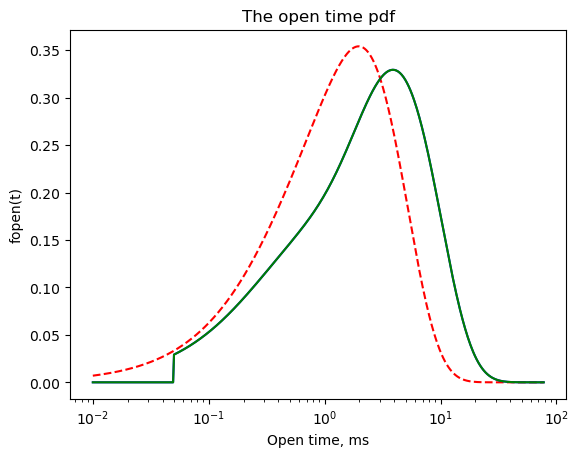

In [8]:
t, ipdf, epdf, apdf = scpl.open_time_pdf(demomec, tres)
plt.semilogx(t, ipdf, 'r--', t, epdf, 'b-', t, apdf, 'g-')
plt.ylabel('fopen(t)')
plt.xlabel('Open time, ms')
plt.title('The open time pdf')
print('RED- ideal distribution\nGREEN- HJC distribution (corrected for missed events)')

Print shut time distribution:

In [9]:
# Print shut time pdf's

print(demo_matrix.print_shut_time_pdf)

print(demo_asymp.print_asymptotic_shut_time_pdf)

print(demo_exact.shut_time_pdf)



Ideal shut time PDF components, unconditional
|   Term |     Amplitude |   Rate (1/sec) |     tau (ms) |   Area (%) |
|--------+---------------+----------------+--------------+------------|
|      1 |     0.0691263 |       0.263895 | 3789.38      |  26.1946   |
|      2 |    17.2607    |    2062.93     |    0.484747  |   0.836704 |
|      3 | 13872.7       |   19011.8      |    0.0525989 |  72.9687   |
Mean (ms) = 992.65		SD = 2556.8		SD/mean = 2.5758



ASYMPTOTIC SHUT TIME DISTRIBUTION
|   Term |   Rate (1/sec) |     tau (ms) |   Area (%) |   Area renormalised for t=0 to inf |
|--------+----------------+--------------+------------+------------------------------------|
|      1 |   18405.7      |    0.0543309 |   51.5164  |                          72.7667   |
|      2 |    2060.47     |    0.485325  |    1.30946 |                           0.816856 |
|      3 |       0.253051 | 3951.77      |   46.9416  |                          26.4165   |
Apparent mean shut time (ms): 1855.2


E

Plot shut time distribution:

RED- ideal distribution
GREEN- HJC distribution (corrected for missed events)


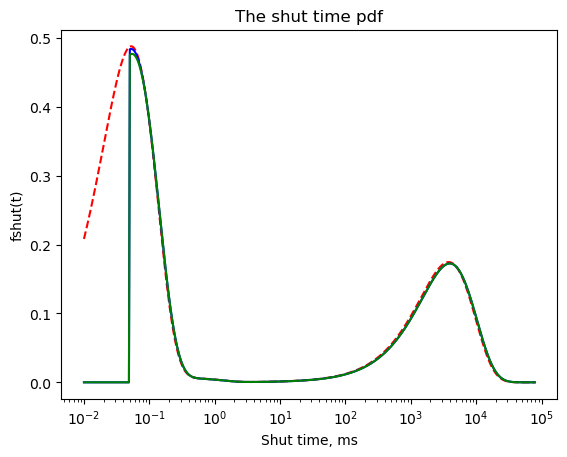

In [10]:
t, ipdf, epdf, apdf = scpl.shut_time_pdf(demomec, tres)
plt.semilogx(t, ipdf, 'r--', t, epdf, 'b-', t, apdf, 'g-')
plt.ylabel('fshut(t)')
plt.xlabel('Shut time, ms')
plt.title('The shut time pdf')
print('RED- ideal distribution\nGREEN- HJC distribution (corrected for missed events)')

Display open time adjacent to shut time range pdf:

In [11]:
u1, u2 = 0.1e-3, 1e-3 # 1 ms, 10 ms

from scalcs.scprint import AdjacentPDFPrints
pdf_adjacent = AdjacentPDFPrints(demomec.Q, demomec.kA, demomec.kB, demomec.kC, demomec.kD, tres=tres)
print(pdf_adjacent.ideal_adjacent_dwells(u1, u2))

t, ipdf, ajpdf = scpl.adjacent_open_time_pdf(demomec, tres, u1, u2)
plt.semilogx(t, ipdf, 'r--', t, ajpdf, 'b-')
print('Ideal open time pdf- red dashed line.\n' +
'Open times adjacent to shut time range pdf- blue solid line.\n')


PDF of open times that precede shut times between 0.100 and 1.000 ms

OPEN TIMES ADJACENT TO SPECIFIED SHUT TIME RANGE
|   Term |   Amplitude |   Rate (1/sec) |   tau (ms) |   Area (%) |
|--------+-------------+----------------+------------+------------|
|      1 |    494.604  |        500.654 |   1.99739  |   98.7916  |
|      2 |     36.8556 |       3050.01  |   0.327867 |    1.20838 |
Mean (ms) = 1.9772		SD = 1.994		SD/mean = 1.0085
Mean from direct calculation (ms) = 1.977215



AttributeError: module 'scalcs.pdfs' has no attribute 'expPDF'

Display mean open time preceding / next-to shut time plot:

Mean open time preceding specified shut time- red dashed line.
Mean open time next to specified shut time- blue dashed line.


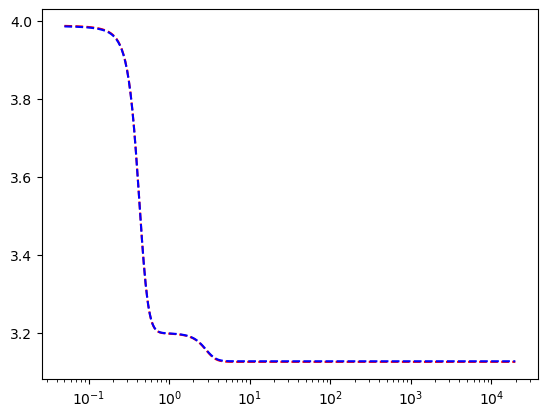

In [ ]:
sht, mp, mn = scpl.mean_open_next_shut(demomec, tres)
plt.semilogx(sht, mp, 'r--', sht, mn, 'b--')
print('Mean open time preceding specified shut time- red dashed line.\n' +
'Mean open time next to specified shut time- blue dashed line.')

Display subset time pdf:

In [ ]:
state1 = 3
state2 = 4
#t, ipdf, spdf = scpl.subset_time_pdf(demomec, tres, state1, state2)
#plt.semilogx(t, spdf, 'b-', t, ipdf, 'r--')
print('Ideal pdf- red dashed line.\nSubset life time pdf- blue solid line.')

Ideal pdf- red dashed line.
Subset life time pdf- blue solid line.


Display dependency plot:

In [ ]:
to, ts, d = scpl.dependency_plot(demomec, tres, points=128)
fig = plt.figure()
fig.suptitle('Dependency plot', fontsize=12)
ax = fig.gca(projection='3d')
to, ts = np.meshgrid(to, ts)
surf = ax.plot_surface(to, ts, d, rstride=1, cstride=1, cmap=cm.coolwarm,
    linewidth=0, antialiased=False)
ax.set_zlim(-1.0, 1.0)

TypeError: FigureBase.gca() got an unexpected keyword argument 'projection'

<Figure size 640x480 with 0 Axes>

##### Macroscopic response to agonist concentration pulse

Define a realistic profile of concentration pulse:

In [ ]:
# Here one can tweak the parameters of the jump.
step_size = 8e-6 # The sample step. All time parameters in seconds
pulse_centre = 10e-3
rise_time = 250e-6 # 10-90% rise time for error functions
pulse_width = 10e-3
record_length = 50e-3
peak_conc = 10e-6    # in M
baseline_conc = 0.0
cjargs = (peak_conc, baseline_conc, pulse_centre, pulse_width,
            rise_time, rise_time)

GREEN- concentration pulse profile
BLUE- open probability profile


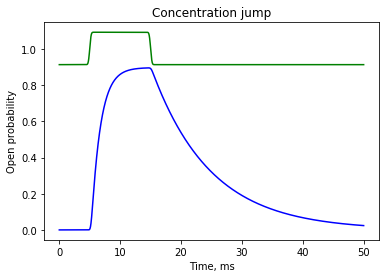

In [ ]:
t, c, Popen, P  = cjumps.solve_jump(demomec, record_length, step_size,
        cjumps.pulse_erf, cjargs)
maxP = max(Popen)
maxC = max(c)
c1 = (c / maxC) * 0.2 * maxP + 1.02 * maxP

plt.plot(t * 1000, Popen,'b-', t * 1000, c1, 'g-')
plt.ylabel('Open probability')
plt.xlabel('Time, ms')
plt.title('Concentration jump')
print('GREEN- concentration pulse profile\nBLUE- open probability profile')

Calculate properties of a macroscopic response to an ideal square pulse:

In [ ]:
print (cjumps.printout(demomec, peak_conc, pulse_width))


*******************************************
CONCENTRATION JUMPS

Equilibrium occupancies before t=0, at concentration = 0.0:
p00(1) = -0
p00(2) = -0
p00(3) = -0
p00(4) = -0
p00(5) = 1

Equilibrium occupancies at maximum concentration = 0.01 mM:
pinf(1) = 0.00011975
pinf(2) = 0.8981
pinf(3) = 0.023949
pinf(4) = 0.029937
pinf(5) = 0.047898

Occupancies at the end of 10 ms pulse:
pt(1) = 0.00012
pt(2) = 0.89679
pt(3) = 0.024133
pt(4) = 0.029951
pt(5) = 0.049008

ON-RELAXATION for ideal step:
Time course for current

Comp	Eigen		Tau (ms)
1	-20828		0.048012	
2	-8017.9		0.12472	
3	-6001.6		0.16662	
4	-668.16		1.4966	

Ampl.(t=0,pA)	Rel.ampl.		Area(pC)
0.028943		-0.011554		0.0013896	
-0.0028676		0.0011447		-0.00035766	
-0.37551		0.1499		-0.062568	
2.5052		-1		3.7493	

Weighted On Tau (ms) = 1.4721

Total current at t=0 (pA) = 4.4409e-16
Total current at equilibrium (pA) = -2.1557
Total area (pC) = 0.0036878
Current at the end of 10 ms pulse = -2.1526

OFF-RELAXATION for ideal step:
Time cour